# Tutorial 4: HD data(MSI)

Here, we apply GraphPCA-Turbo to analyze a HD spatial transcriptomics sample from the Mouse Small Intestine(MSI). GraphPCA-Turbo is a highly scalable enhancement of GraphPCA that reformulates the optimization problem as sparse, symmetric positive-definite linear systems solved via an alternating iteration strategy. The intestine is a highly organized organ characterized by its complex vertical architecture, ranging from the deep crypts to the mature villus tips.MSI dataset can be download from 10x Genomics Visium HD website (https://www.10xgenomics.com/datasets/visium-hd-cytassist-gene-expression-libraries-of-mouse-intestine)

## Load packages

In [ ]:
import GraphPCA as sg
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
from sklearn.cluster import KMeans

%config InlineBackend.figure_format = 'retina'

## Load data

In [2]:
adata = sc.read_h5ad('../data/after_gpca_008um_0306.h5ad')

## Preprocessing

In [3]:
sc.pp.filter_cells(adata,min_counts=100)
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
adata

AnnData object with n_obs × n_vars = 308813 × 19059
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'n_counts', 'GPCA_pred_7'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'GPCA_pred_7_colors', 'log1p', 'spatialdata_attrs'
    obsm: 'spatial'

## Perform GraphPCA-Turbo

In GraphPCA-Turbo, we have significantly refactored the computational core to introduce a high-performance accelerated mode. By leveraging a C++ backend powered by Eigen3 and pybind11, the algorithm achieves a 5x to 20x speedup compared to standard implementations.

In [4]:
Z, W = sg.Run_GPCA(
    adata,
    location=adata.obsm["spatial"],
    n_components=50, 
    method="knn", 
    n_neighbors=6, 
    _lambda=0.5,
    max_iter=10,
    mode='accelerated'
)

Reached maximum iterations (10) without convergence.


In [5]:
adata.obsm["GraphPCA-Turbo"] = Z
print(Z.shape)

(308813, 50)


## Clustering

In [6]:
estimator = KMeans(n_clusters=7,random_state=101)
res = estimator.fit(Z[:,:])
lable_pred=res.labels_
adata.obs["GPCA_pred_7"]= lable_pred
adata.obs["GPCA_pred_7"] = adata.obs["GPCA_pred_7"].astype('category')

d:\Miniconda3\envs\sctm\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


## Visualization

d:\Miniconda3\envs\sctm\lib\site-packages\squidpy\pl\_spatial_utils.py:955: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


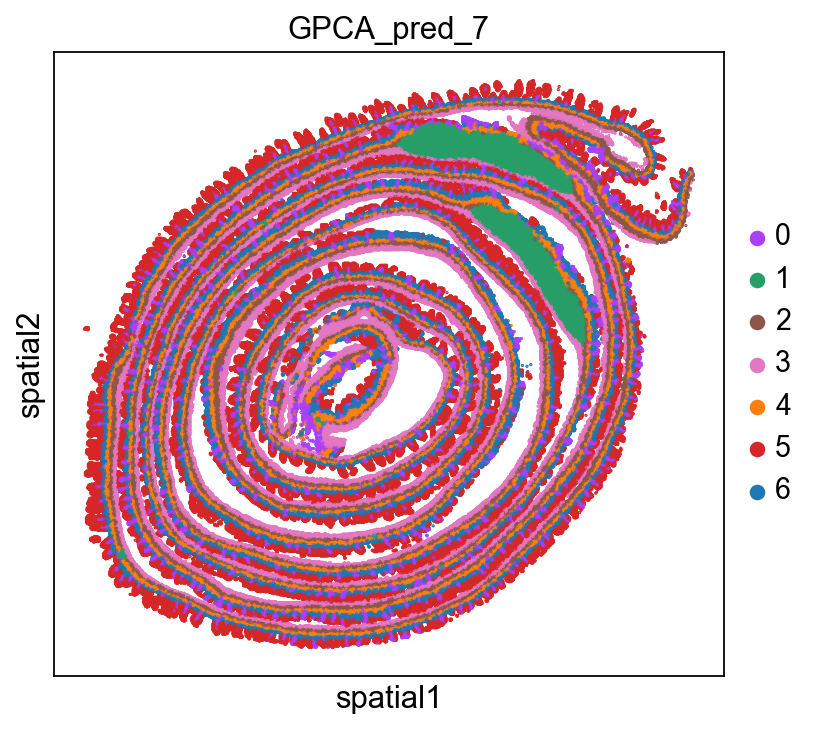

In [7]:
sc.set_figure_params(color_map = 'Set1',figsize=(5,5))
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "GPCA_pred_7",
    ],
    wspace=0.4
)

## ROI Analysis

Read the csv of roi point information

In [8]:
roi_info_from_csv = pd.read_csv('../data/roi_points_info.csv', index_col=0)
selected_indices = roi_info_from_csv.index
adata = adata[adata.obs_names.isin(selected_indices)].copy()
print(f"Extracted ROI adata: {adata.n_obs} cells")

Extracted ROI adata: 1347 cells


d:\Miniconda3\envs\sctm\lib\site-packages\squidpy\pl\_spatial_utils.py:955: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


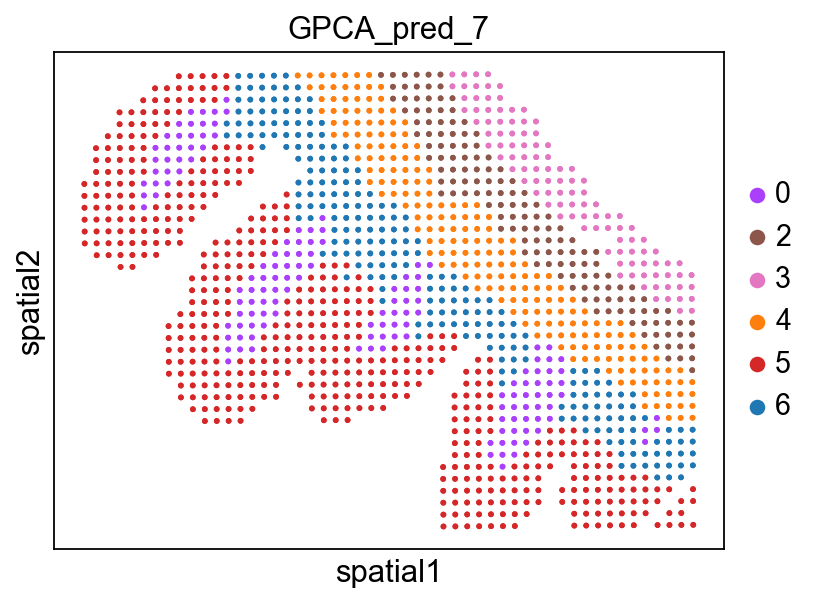

In [9]:
sc.set_figure_params(color_map = 'Set1',figsize=(5,5))
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "GPCA_pred_7",
    ],
    wspace=0.4,
    size=10,
)